# French Corporate Network — Annuaire des Entreprises

This notebook builds a **corporate officer network** from the French government's open data API: the [Annuaire des Entreprises](https://annuaire-entreprises.data.gouv.fr/) (data.gouv.fr).

For a set of major French companies, we fetch their registered officers (*dirigeants*) and auditors, then load the resulting bipartite graph into TuringDB using `LOAD JSONL`.

## Graph model
- **`Company` nodes** — identified by SIREN number, with sector and category attributes
- **`Person` nodes** — individuals holding a mandate, with birth year
- **`IS_OFFICER_OF` edges** — links a company to one of its officers, with the role (`qualite`) as a property
- **`IS_AUDITOR_OF` edges** — links a company to one of its statutory auditors (also a company)

## Questions we can answer
- Which companies have the most officers?
- Who sits on the most boards (interlocking directorates)?
- What is the approximate age of company officers?
- Which CEOs (*Directeur Général*) are shared across multiple companies?

**Data source**: `recherche-entreprises.api.gouv.fr` — free, no authentication required, official data.gouv.fr infrastructure.

## 1. Setup

In [1]:
import os
import time
import json
import requests
import pandas as pd
import networkx as nx
from IPython.display import display
from dotenv import load_dotenv

import turingdb
from turingdb_examples.graph import networkx_to_jsonl
from turingdb_examples.llm import natural_language_to_cypher

load_dotenv()

True

In [2]:
graph_name = "french_corporate_network"
example_name = "french_corporate_network"
path_data = f"{os.getcwd()}/data/{example_name}"
os.makedirs(path_data, exist_ok=True)

API_URL = "https://recherche-entreprises.api.gouv.fr/search"

# Major French companies — subset of CAC 40 with confirmed French SIREN numbers
COMPANIES = [
    "Air Liquide",
    "Airbus",
    "AXA",
    "BNP Paribas",
    "Bouygues",
    "Capgemini",
    "Carrefour",
    "Crédit Agricole",
    "Danone",
    "Dassault Systèmes",
    "Engie",
    "Hermès International",
    "Kering",
    "Legrand",
    "L'Oréal",
    "LVMH",
    "Orange",
    "Pernod Ricard",
    "Publicis Groupe",
    "Renault",
    "Safran",
    "Sanofi",
    "Schneider Electric",
    "Société Générale",
    "Teleperformance",
    "Thales",
    "TotalEnergies",
    "Veolia",
    "Vinci",
    "Vivendi",
]

print(f"Will fetch data for {len(COMPANIES)} companies")

Will fetch data for 30 companies


## 2. Fetch data from the Annuaire des Entreprises API

In [3]:
%%time

raw_companies = []

for name in COMPANIES:
    resp = requests.get(API_URL, params={"q": name, "per_page": 1})
    resp.raise_for_status()
    results = resp.json().get("results", [])
    if not results:
        print(f"  ⚠ Not found: {name}")
        continue
    company = results[0]
    raw_companies.append(company)
    print(f"  ✓ {company['nom_complet']} (SIREN: {company['siren']}) — {len(company.get('dirigeants', []))} dirigeants")
    time.sleep(0.15)  # be polite to the API

print(f"\nFetched {len(raw_companies)} companies")

  ✓ AIR LIQUIDE FRANCE INDUSTRIE (SIREN: 314119504) — 6 dirigeants
  ✓ AIRBUS (SIREN: 383474814) — 6 dirigeants
  ✓ AXA (SIREN: 411035363) — 0 dirigeants
  ✓ BNP PARIBAS (HELLO BANK!) (SIREN: 662042449) — 19 dirigeants
  ✓ BOUYGUES (SIREN: 572015246) — 19 dirigeants
  ✓ CAPGEMINI (SIREN: 330703844) — 17 dirigeants
  ✓ CARREFOUR (SIREN: 503932568) — 0 dirigeants
  ✓ CREDIT AGRICOLE DU MORBIHAN (SIREN: 777903816) — 20 dirigeants
  ✓ DANONE (SIREN: 552032534) — 13 dirigeants
  ✓ DASSAULT SYSTEMES (SIREN: 322306440) — 16 dirigeants
  ✓ ENGIE (SIREN: 542107651) — 16 dirigeants
  ✓ HERMES INTERNATIONAL (SIREN: 572076396) — 19 dirigeants
  ✓ KERING (SIREN: 552075020) — 18 dirigeants
  ✓ LEGRAND (SIREN: 306618505) — 1 dirigeants
  ✓ L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSIONNEL PARIS ; ESSIE PROFESSIONNEL ; BAXTER OF CALIFORNIA ; BIOL) (SIREN: 632012100) — 20 dirigeants
  ✓ LVMH (SIREN: 908836505) — 2 dirigeants
  ✓ ORANGE (SIREN: 380129866) — 21 dirigeants
  ✓ PERNOD RICARD (SIREN: 5820

## 3. Explore the data

In [4]:
# Build a summary DataFrame
rows = []
for c in raw_companies:
    dirigeants = c.get("dirigeants", [])
    rows.append({
        "siren": c["siren"],
        "nom": c["nom_complet"],
        "secteur": c.get("activite_principale", ""),
        "categorie": c.get("categorie_entreprise", ""),
        "nature_juridique": c.get("nature_juridique", ""),
        "date_creation": c.get("date_creation", ""),
        "nb_personnes_physiques": sum(1 for d in dirigeants if d["type_dirigeant"] == "personne physique"),
        "nb_personnes_morales": sum(1 for d in dirigeants if d["type_dirigeant"] == "personne morale"),
    })

df_companies = pd.DataFrame(rows)
print(f"Companies: {len(df_companies)}")
print(f"Total officers (persons): {df_companies['nb_personnes_physiques'].sum()}")
print(f"Total auditors (firms): {df_companies['nb_personnes_morales'].sum()}")
display(df_companies)

Companies: 30
Total officers (persons): 280
Total auditors (firms): 58


,siren,nom,secteur,categorie,nature_juridique,date_creation,nb_personnes_physiques,nb_personnes_morales
0,314119504,AIR LIQUIDE FRANCE INDUSTRIE,20.11Z,GE,5599,1978-01-01,5,1
1,383474814,AIRBUS,30.30Z,GE,5710,1991-10-18,4,2
2,411035363,AXA,71.12B,PME,5499,1996-07-08,0,0
3,662042449,BNP PARIBAS (HELLO BANK!),64.19Z,GE,5599,1966-07-01,16,3
4,572015246,BOUYGUES,70.10Z,GE,5599,1900-01-01,16,3
5,330703844,CAPGEMINI,70.10Z,GE,5800,1984-09-19,15,2
6,503932568,CARREFOUR,68.32A,None,9110,2007-01-01,0,0
7,777903816,CREDIT AGRICOLE DU MORBIHAN,64.19Z,GE,6596,1900-01-01,17,3
8,552032534,DANONE,70.10Z,GE,5599,1955-01-01,11,2
9,322306440,DASSAULT SYSTEMES,58.29C,GE,5800,1981-11-01,13,3


In [5]:
# Most common officer roles across all companies
all_roles = []
for c in raw_companies:
    for d in c.get("dirigeants", []):
        if d["type_dirigeant"] == "personne physique":
            all_roles.append(d.get("qualite", "Unknown"))

df_roles = pd.Series(all_roles).value_counts().reset_index()
df_roles.columns = ["role", "count"]
print("Top officer roles:")
display(df_roles.head(15))

Top officer roles:


,role,count
0,Administrateur,154
1,Autre,34
2,Membre du conseil de surveillance,19
3,Directeur Général,13
4,Président du conseil d'administration,12
5,Administrateurs représentant les salariés,11
6,Directeur général délégué,8
7,Gérant,8
8,Vice-Président,5
9,Président de SAS,3


## 4. Build the NetworkX graph

In [6]:
G = nx.DiGraph()

for c in raw_companies:
    siren = c["siren"]

    # Add company node
    G.add_node(
        siren,
        type="Company",
        displayName=c["nom_complet"],
        secteur=c.get("activite_principale") or "",
        categorie=c.get("categorie_entreprise") or "",
        date_creation=c.get("date_creation") or "",
    )

    for d in c.get("dirigeants", []):
        qualite = d.get("qualite", "")

        if d["type_dirigeant"] == "personne physique":
            nom = d.get("nom", "")
            prenoms = d.get("prenoms", "")
            annee = d.get("annee_de_naissance")
            person_id = f"{nom}_{prenoms}_{annee or ''}"

            G.add_node(
                person_id,
                type="Person",
                displayName=f"{prenoms} {nom}".strip(),
                nom=nom,
                prenoms=prenoms,
                annee_de_naissance=int(annee) if annee else 0,
            )
            G.add_edge(siren, person_id, type="IS_OFFICER_OF", qualite=qualite)

        elif d["type_dirigeant"] == "personne morale" and d.get("siren"):
            auditor_siren = d["siren"]
            G.add_node(
                auditor_siren,
                type="Company",
                displayName=d.get("denomination", auditor_siren),
                secteur="",
                categorie="",
                date_creation="",
            )
            G.add_edge(siren, auditor_siren, type="IS_AUDITOR_OF", qualite=qualite)

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  Company nodes: {sum(1 for _, d in G.nodes(data=True) if d.get('type') == 'Company')}")
print(f"  Person nodes:  {sum(1 for _, d in G.nodes(data=True) if d.get('type') == 'Person')}")

Graph: 323 nodes, 337 edges
  Company nodes: 54
  Person nodes:  269


## 5. Load into TuringDB

In [9]:
client = turingdb.TuringDB()
print("TuringDB client connected")

TuringDB client connected


In [10]:
%%time

print("Writing graph to JSONL...")
jsonl_filename = networkx_to_jsonl(G, graph_name, node_type_key="type")

print(f"\nLoading JSONL into TuringDB as graph '{graph_name}' ...")
client.query(f"LOAD JSONL '{jsonl_filename}' AS {graph_name}")
client.set_graph(graph_name)
print(f"\n✓ Graph '{graph_name}' ready")

Writing graph to JSONL...
JSONL file written to: /home/ubuntu/.turing/data/french_corporate_network.jsonl
Graph: 323 nodes, 337 edges

Loading JSONL into TuringDB as graph 'french_corporate_network' ...

✓ Graph 'french_corporate_network' ready
CPU times: user 10.4 ms, sys: 3.16 ms, total: 13.5 ms
Wall time: 87.1 ms


## 6. Schema inspection

In [11]:
print("Node labels:")
display(client.query("CALL db.labels()"))

print("Edge types:")
display(client.query("CALL db.edgeTypes()"))

print("Property types:")
display(client.query("CALL db.propertyTypes()"))

Node labels:


,id,label
0,0,Company
1,1,Person


Edge types:


,id,edgeType
0,0,CONNECTED


Property types:


,id,propertyType,valueType
0,0,categorie,String
1,1,date_creation,String
2,2,displayName,String
3,3,id,String
4,4,secteur,String
5,5,type,String
6,6,annee_de_naissance,Int64
7,7,nom,String
8,8,prenoms,String
9,9,qualite,String


## 7. Graph queries

Since all nodes carry a `type` property, we filter semantically using `WHERE n.type = '...'` rather than label syntax.

In [12]:
# Count nodes by type
print("Company nodes:")
display(client.query("""
    MATCH (n) WHERE n.type = 'Company'
    RETURN count(n)
"""))

print("Person nodes:")
display(client.query("""
    MATCH (n) WHERE n.type = 'Person'
    RETURN count(n)
"""))

print("IS_OFFICER_OF edges:")
display(client.query("""
    MATCH ()-[r]->() WHERE r.type = 'IS_OFFICER_OF'
    RETURN count(r)
"""))

print("IS_AUDITOR_OF edges:")
display(client.query("""
    MATCH ()-[r]->() WHERE r.type = 'IS_AUDITOR_OF'
    RETURN count(r)
"""))

Company nodes:


,count(n)
0,54


Person nodes:


,count(n)
0,269


IS_OFFICER_OF edges:


,count(r)
0,280


IS_AUDITOR_OF edges:


,count(r)
0,57


In [13]:
# Sample companies with their officers
print("Sample officer relationships:")
display(client.query("""
    MATCH (c)-[r]->(p)
    WHERE c.type = 'Company' AND p.type = 'Person' AND r.type = 'IS_OFFICER_OF'
    RETURN c.displayName, p.displayName, r.qualite
    LIMIT 15
"""))

Sample officer relationships:


,c.displayName,p.displayName,r.qualite
0,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,SOPHIE BELLON,Administrateur
1,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,PAUL BULCKE,Administrateur
2,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,PATRICE CAINE,Administrateur
3,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,BENNY DE VLIEGER,Administrateurs représentant les salariés
4,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,FABIENNE DULAC,Administrateur
5,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,BEATRICE GRABISCH (GUILLAUME),Administrateur
6,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,THIERRY HAMEL,Autre
7,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,NICOLAS HIERONIMUS,Autre
8,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,AURÉLIE JEAN,Administrateur
9,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,ILHAM KADRI,Administrateur


In [14]:
# Filter by role: Directeurs Généraux
print("Directeurs Généraux across all companies:")
display(client.query("""
    MATCH (c)-[r]->(p)
    WHERE c.type = 'Company' AND p.type = 'Person'
    AND r.qualite = 'Directeur Général'
    RETURN c.displayName, p.displayName
    LIMIT 30
"""))

Directeurs Généraux across all companies:


,c.displayName,p.displayName
0,ENGIE,CATHERINE MACGREGOR (FIAMMA)
1,DASSAULT SYSTEMES,PASCAL DALOZ
2,DANONE,ANTOINE BERNARD DE SAINT AFFRIQUE
3,CREDIT AGRICOLE DU MORBIHAN,CHRISTOPHE PIERRE JEAN MARIE GRELIER
4,CAPGEMINI,AIMAN EZZAT
5,SANOFI,PAUL HUDSON
6,SAFRAN,OLIVIER ANDRIÈS
7,ORANGE,CHRISTEL HEYDEMANN
8,BOUYGUES,OLIVIER ROUSSAT
9,AIRBUS,CARMEN-MAJA REX


In [17]:
# Filter by role: Présidents du conseil d'administration
print("Présidents du conseil d'administration:")
display(client.query("""
    MATCH (c)-[r]->(p)
    WHERE c.type = 'Company' AND p.type = 'Person'
    AND r.qualite = "Président du conseil d'administration"
    RETURN c.displayName, p.displayName
    LIMIT 30
"""))

Présidents du conseil d'administration:


,c.displayName,p.displayName
0,L'OREAL (KERASTASE ; MIZANI ; L'OREAL PROFESSI...,JEAN-PAUL AGON
1,KERING,FRANCOIS JEAN HENRI PINAULT
2,ENGIE,JEAN PIERRE LUC CLAMADIEU
3,DASSAULT SYSTEMES,BERNARD JOSEPH MARIE CHARLES
4,DANONE,GILLES SCHNEPP
5,CAPGEMINI,PAUL HERMELIN
6,SOCIETE GENERALE (SG),LORENZO BINI SMAGHI
7,SANOFI,FREDERIC OUDÉA
8,SAFRAN,ROSS MC INNES
9,ORANGE,JACQUES ASCHENBROICH


In [18]:
# Persons with mandates in multiple companies (interlocking directorates)
# We find persons who appear as officers more than once
print("Persons with mandates in multiple companies (interlocking directorates):")
df_officers = client.query("""
    MATCH (c)-[r]->(p)
    WHERE c.type = 'Company' AND p.type = 'Person' AND r.type = 'IS_OFFICER_OF'
    RETURN p.displayName, c.displayName, r.qualite
    LIMIT 1000
""")

# Find persons appearing in more than one company
mandates_per_person = df_officers.groupby("p.displayName")["c.displayName"].count().reset_index()
mandates_per_person.columns = ["person", "nb_mandates"]
interlocking = mandates_per_person[mandates_per_person["nb_mandates"] > 1].sort_values("nb_mandates", ascending=False)

print(f"Found {len(interlocking)} persons with mandates in multiple companies:")
display(interlocking)

Persons with mandates in multiple companies (interlocking directorates):
Found 10 persons with mandates in multiple companies:


,person,nb_mandates
54,CELINE FORNARO,3
12,ANNE GABRIELLE HEILBRONNER,2
65,CHRISTOPHE BABULE,2
86,ESTELLE KARINE BRACHLIANOFF,2
97,FREDERIC OUDÉA,2
122,JACQUES ASCHENBROICH,2
154,LISE KINGO,2
185,MONIQUE COHEN (AYACHE),2
202,PATRICE CAINE,2
264,XIAOYING DUAN,2


## 8. Expression evaluation — Approximate age of officers

Since TuringDB v1.22, arithmetic expressions are supported directly in `RETURN` projections.
Here we compute the approximate age of each officer from their birth year.

In [19]:
# Approximate age of officers using expression evaluation in RETURN (TuringDB v1.22)
print("Approximate age of company officers (2025 - birth year):")
df_ages = client.query("""
    MATCH (p) WHERE p.type = 'Person' AND p.annee_de_naissance > 0
    RETURN p.displayName, p.annee_de_naissance, 2025 - p.annee_de_naissance
    LIMIT 20
""")
df_ages.columns = ["officer", "birth_year", "approx_age"]
display(df_ages)

Approximate age of company officers (2025 - birth year):


,officer,birth_year,approx_age
0,MONIQUE COHEN (AYACHE),1956,69
1,JACQUES ASCHENBROICH,1954,71
2,THI THU HUONG CAO DAC (NGUYEN),1984,41
3,MINH CAO DAC,1978,47
4,FANNY NATHALIE CHRISTINE RENAULT (LECOSSOIS),1991,34
5,WILLIAM JOHN RÉMI RENAULT,1991,34
6,YANN NICOLAS GERARDIN,1961,64
7,OLIVIER ANDRIÈS,1962,63
8,ANNE AUBERT,1971,54
9,PATRICIA SUZANNE BELLINGER,1961,64


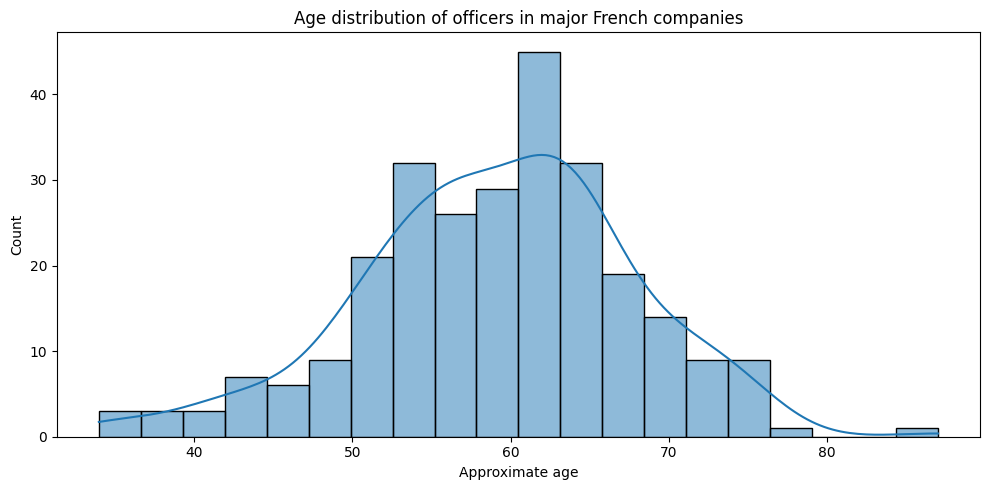

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of approximate ages
df_all_ages = client.query("""
    MATCH (p) WHERE p.type = 'Person' AND p.annee_de_naissance > 0
    RETURN 2025 - p.annee_de_naissance
""")
df_all_ages.columns = ["approx_age"]

plt.figure(figsize=(10, 5))
sns.histplot(df_all_ages["approx_age"], bins=20, kde=True)
plt.xlabel("Approximate age")
plt.ylabel("Count")
plt.title("Age distribution of officers in major French companies")
plt.tight_layout()
plt.show()

## 9. Visualization

In [21]:
from pyvis.network import Network

# Build a subgraph: only CEO-level officers (Directeur Général / Président)
key_roles = {"Directeur Général", "Président du conseil d'administration", "Président Directeur Général"}

G_sub = nx.DiGraph()
for src, tgt, attrs in G.edges(data=True):
    if attrs.get("qualite") in key_roles:
        G_sub.add_node(src, **G.nodes[src])
        G_sub.add_node(tgt, **G.nodes[tgt])
        G_sub.add_edge(src, tgt, **attrs)

print(f"Subgraph (key roles only): {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")

net = Network(height="600px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

for node_id, attrs in G_sub.nodes(data=True):
    label = attrs.get("displayName", str(node_id))
    if attrs.get("type") == "Company":
        net.add_node(str(node_id), label=label, color="#4A90D9", size=20, title=f"Company: {label}")
    else:
        net.add_node(str(node_id), label=label, color="#E07B39", size=12, title=f"Officer: {label}")

for src, tgt, attrs in G_sub.edges(data=True):
    net.add_edge(str(src), str(tgt), title=attrs.get("qualite", ""), color="#888888")

viz_path = f"{path_data}/corporate_network.html"
net.save_graph(viz_path)
print(f"Visualization saved to {viz_path}")
net.show(viz_path)

Subgraph (key roles only): 39 nodes, 25 edges
Visualization saved to /home/ubuntu/turingdb-examples/examples/notebooks/public_version/data/french_corporate_network/corporate_network.html
/home/ubuntu/turingdb-examples/examples/notebooks/public_version/data/french_corporate_network/corporate_network.html


## 10. Natural language to Cypher (LLM)

We use an LLM to translate natural language questions into TuringDB Cypher queries.

In [22]:
api_keys = {
    "OpenAI": os.getenv("OPENAI_API_KEY"),
    "Mistral": os.getenv("MISTRAL_API_KEY"),
    "Anthropic": os.getenv("ANTHROPIC_API_KEY"),
}

In [23]:
turingdb_cypher_system_prompt = """\
You are a TuringDB graph database expert. TuringDB uses a subset of openCypher.
Generate ONLY valid TuringDB queries — never use unsupported clauses or functions.

## SUPPORTED SYNTAX

### Basic patterns
MATCH (n)                           -- all nodes
MATCH (n:Label)                     -- nodes with a specific label (only when labels are semantic)
MATCH (n {prop: 'value'})           -- inline property filter
MATCH (a)-[r:REL_TYPE]->(b)         -- directed relationship (only when rel types are semantic)
MATCH (a)-[r]->(b)                  -- directed relationship (generic)
MATCH (a)-[r]-(b)                   -- undirected relationship

### Return / filtering
RETURN n.property
RETURN n, r, m
RETURN n LIMIT 10
RETURN n SKIP 10 LIMIT 10
WHERE n.property = 'value'
WHERE n.property <> 'value'
WHERE n.property > 42  |  >= 42  |  < 42  |  <= 42
WHERE n.property IS NULL  |  IS NOT NULL
WHERE n.prop = 'a' AND m.prop = 'b'
WHERE n.prop = 'a' OR n.prop = 'b'

### Arithmetic expressions in RETURN
RETURN n.price * 1.1                -- multiply by constant
RETURN n.amount / 1000.0            -- divide by constant
RETURN n.value + n.tax              -- add two properties
RETURN 2025 - n.birth_year          -- compute age from birth year

### Aggregation
RETURN count(n)

### Schema introspection
CALL db.labels()
CALL db.edgeTypes()
CALL db.propertyTypes()

## STRICTLY FORBIDDEN (will cause errors)
- SKIP (standalone, without LIMIT)
- WITH
- RETURN *
- DISTINCT
- ORDER BY
- CREATE, MERGE, DELETE, SET, REMOVE
- UNION, subqueries: CALL { ... }
- Variable-length / multi-hop paths: [*2], [*1..3]
- Aggregation functions other than count(): sum(), avg(), min(), max()
- String functions: toLower(), toUpper(), contains(), startsWith(), endsWith(), trim()
- Math functions: abs(), round(), sqrt()
- List comprehensions, named paths
- Variable names `end` or `start` (reserved) — use `e`, `s`, or other aliases
- Double-quoted strings — always single quotes: WHERE n.name = 'Alice'

## SCHEMA CONTEXT
NODE LABELS
{node_labels}

RELATIONSHIP TYPES
{rel_types}

PROPERTIES
{properties}

SAMPLE DATA
{sample_data}

## INSTRUCTIONS
1. Follow the filtering guidance in the schema context exactly.
2. Use ONLY labels, relationship types, and property names listed above.
3. Always use single quotes for string literals.
4. Arithmetic expressions in RETURN are supported — use them when the question implies a calculation.
5. If the query cannot be expressed in supported syntax, say so explicitly instead of generating an invalid query.
6. Return ONLY the raw Cypher query — no markdown formatting, no code blocks, no backticks, no explanations before or after.
"""

In [40]:
# Discover schema
_labels     = client.query("CALL db.labels()")
_edge_types = client.query("CALL db.edgeTypes()")
_props      = client.query("CALL db.propertyTypes()")

_label_vals   = _labels.iloc[:, 1].tolist()
_edgetype_vals = _edge_types.iloc[:, 1].tolist()
_prop_names   = _props.iloc[:, 1].tolist()

# Node labels section
if set(_label_vals) <= {"Node"}:
    _node_labels_text = "All nodes use the generic label 'Node'. DO NOT use MATCH (n:SomeLabel) syntax."
    if "type" in _prop_names:
        _type_vals = client.query("MATCH (n) WHERE n.type IS NOT NULL RETURN n.type LIMIT 50")
        #_type_vals = list(np.unique(_type_vals.values))
        _node_labels_text += f"\nFilter by semantic type using WHERE n.type = '<value>'. Available values: {np.unique(_type_vals.iloc[:, 0].tolist())}"
else:
    _node_labels_text = f"Use MATCH (n:Label) syntax. Available labels: {_label_vals}"

# Edge types section
if set(_edgetype_vals) <= {"CONNECTED"}:
    _rel_types_text = "All relationships use generic type 'CONNECTED'. DO NOT use -[:REL_TYPE]-> syntax."
    if "type" in _prop_names:
        _rtype_vals = client.query("MATCH ()-[r]->() WHERE r.type IS NOT NULL RETURN r.type LIMIT 50")
        #_rtype_vals = list(np.unique(_rtype_vals.values))
        _rel_types_text += f"\nFilter by semantic type using WHERE r.type = '<value>'. Available values: {np.unique(_rtype_vals.iloc[:, 0].tolist())}"
else:
    _rel_types_text = f"Use -[:TYPE]-> syntax. Available types: {_edgetype_vals}"

# Sample nodes
_sample_props = [p for p in ["type", "displayName", "qualite", "annee_de_naissance"] if p in _prop_names]
_sample_data = client.query(f"MATCH (n) RETURN {', '.join(f'n.{p}' for p in _sample_props)} LIMIT 5")

system_prompt = turingdb_cypher_system_prompt.replace("{node_labels}", _node_labels_text) \
                                              .replace("{rel_types}", _rel_types_text) \
                                              .replace("{properties}", _props.iloc[:, 1:].to_string(index=False)) \
                                              .replace("{sample_data}", _sample_data.to_string(index=False))
print("System prompt ready")

System prompt ready


In [41]:
import numpy as np

In [43]:
_node_labels_text

"Use MATCH (n:Label) syntax. Available labels: ['Company', 'Person']"

In [44]:
_rel_types_text

"All relationships use generic type 'CONNECTED'. DO NOT use -[:REL_TYPE]-> syntax.\nFilter by semantic type using WHERE r.type = '<value>'. Available values: ['IS_AUDITOR_OF' 'IS_OFFICER_OF']"

In [45]:
%%time

provider = "Anthropic"
question = "Which companies have officers born before 1960?"

cypher_query = natural_language_to_cypher(
    question=question,
    system_prompt=system_prompt,
    provider=provider,
    model="claude-haiku-4-5-20251001",
    api_key=api_keys[provider],
)
print(f"Question: {question}")
print(f"Generated query:\n{cypher_query}")

Question: Which companies have officers born before 1960?
Generated query:
MATCH (c:Company)-[r]-(p:Person) WHERE r.type = 'IS_OFFICER_OF' AND p.annee_de_naissance < 1960 RETURN c
CPU times: user 120 ms, sys: 4.71 ms, total: 125 ms
Wall time: 1.04 s


In [46]:
%%time

result = client.query(cypher_query)
display(result)

,c
0,1
1,1
2,1
3,6
4,6
5,6
6,6
7,9
8,9
9,10


CPU times: user 15.8 ms, sys: 4 μs, total: 15.8 ms
Wall time: 14.5 ms


In [49]:
%%time

provider = "Anthropic"
question = "How many officers does each company have?"

cypher_query = natural_language_to_cypher(
    question=question,
    system_prompt=system_prompt,
    provider=provider,
    model="claude-haiku-4-5-20251001",
    api_key=api_keys[provider],
)
print(f"Question: {question}")
print(f"Generated query:\n{cypher_query}")
try:
    display(client.query(cypher_query))
except turingdb.exceptions.TuringDBException as e:
    print(f"\nTuringDBException: {e}\n")

Question: How many officers does each company have?
Generated query:
MATCH (c:Company)-[r]-(p:Person) WHERE r.type = 'IS_OFFICER_OF' RETURN c.displayName, count(p) LIMIT 100

TuringDBException: PLAN_ERROR: Group by keys are not supported yet

CPU times: user 13.8 ms, sys: 4.85 ms, total: 18.6 ms
Wall time: 796 ms
